<a href="https://colab.research.google.com/github/lipchenko/machine_learning_lipchenko/blob/main/my_clustering_hw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Задание по кластеризации (K‑Means, DBSCAN, OPTICS)

## Данные
**Wine Quality Dataset** (`wineqr.csv`)  
Признаки: химический состав вина (11 числовых признаков)  
Целевая переменная `quality` **не используется** — кластеризация без учителя.

---

## Часть 1. K‑Means (обязательно)

1. Загрузите данные, удалите столбец `quality`, выполните **масштабирование** (StandardScaler).
2. Для `K` от 2 до 10:
   - Обучите K‑Means
   - Вычислите WCSS и коэффициент силуэта
3. Постройте **два графика**: метод локтя (WCSS) и средний силуэт.
4. Выберите оптимальное `K` по силуэту.
5. Обучите финальную модель K‑Means с выбранным `K`.
6. С помощью PCA (2 компоненты) визуализируйте кластеры.
7. Выведите силуэт финальной модели.

---

## Часть 2. DBSCAN (самостоятельный разбор)

**Перед выполнением изучите документацию:**  
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html

### Задания

1. Постройте **k‑distance graph** для `min_samples = 5, 10, 15`.  
   *Код можно взять из туториала или документации.*

2. Методом перебора (`eps` от 0.3 до 1.1 с шагом 0.1, `min_samples` = 5, 10, 15) найдите параметры, дающие **максимальный силуэт** (число кластеров ≥ 2, шум не более 80% данных).

3. Обучите DBSCAN с лучшими параметрами.

4. Визуализируйте результат через PCA (точки шума — отдельным цветом/меткой).

5. **Ответьте на вопросы (письменно):**
   - Почему для DBSCAN критически важно масштабировать данные?
   - Что будет при слишком маленьком `eps`? Слишком большом?
   - Что означают точки с меткой `-1`?
   - Чем DBSCAN принципиально отличается от K‑Means по форме кластеров?

---

## Часть 3. OPTICS (домашнее задание)

**Изучите документацию:**  
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.OPTICS.html

### Задания

1. Обучите OPTICS на тех же данных с параметрами:
   - `min_samples = 10`
   - `xi = 0.05`
   - `min_cluster_size = 0.05`

2. Выведите:
   - количество найденных кластеров
   - количество шумовых точек
   - коэффициент силуэта

3. Постройте:
   - визуализацию кластеров через PCA
   - **reachability plot** (график достижимости)

4. **Ответьте на вопросы (письменно, развёрнуто):**
   - Чем OPTICS отличается от DBSCAN? Укажите **два ключевых отличия**.
   - Что такое параметр `xi` (кси) и как он влияет на выделение кластеров?
   - В каком случае OPTICS даст результат, существенно лучший, чем DBSCAN? Приведите пример.
   - Сравните время работы DBSCAN и OPTICS на ваших данных (можно замерить через `%timeit` или `time.time()`).
   - Судя по визуализациям, какой алгоритм (K‑Means, DBSCAN, OPTICS) лучше разделил данные? Почему?

---

## Критерии оценки (всего 100 баллов)

| Раздел | Что проверяется | Баллы |
|--------|----------------|-------|
| **K‑Means** | Загрузка, масштабирование, цикл по K, графики, выбор K, финальная модель, визуализация, вывод силуэта | 25 |
| **DBSCAN — код** | k‑distance graph, перебор параметров, нахождение лучших, финальная модель, визуализация | 25 |
| **DBSCAN — вопросы** | 4 вопроса, каждый до 5 баллов за полноту и точность | 20 |
| **OPTICS — код** | Обучение, вывод метрик, PCA‑визуализация, reachability plot | 15 |
| **OPTICS — вопросы** | 5 вопросов, каждый до 3 баллов (развёрнутость + понимание) | 15 |

### Дополнительные требования
- Код должен быть **воспроизводимым** (фиксированный `random_state` где нужно)
- Ноутбук должен содержать **markdown‑ячейки с ответами** на вопросы
- Визуализации должны иметь подписи осей и заголовки
- Допускается использование `PCA` для визуализации, но не для обучения

---

## Формат сдачи
- **Jupyter Notebook** (`.ipynb`)
- Файл должен открываться и выполняться от начала до конца без ошибок
- Все ответы на вопросы — внутри ноутбука (markdown)

# Часть 1. K-means

In [78]:
!wget https://raw.githubusercontent.com/milaan9/Clustering-Datasets/refs/heads/master/01.%20UCI/wineqr.csv

--2026-05-04 20:01:01--  https://raw.githubusercontent.com/milaan9/Clustering-Datasets/refs/heads/master/01.%20UCI/wineqr.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84143 (82K) [text/plain]
Saving to: ‘wineqr.csv.4’

wineqr.csv.4        100%[===================>]  82.17K  --.-KB/s    in 0.01s   

2026-05-04 20:01:01 (5.62 MB/s) - ‘wineqr.csv.4’ saved [84143/84143]



In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, OPTICS
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

In [80]:
df = pd.read_csv('wineqr.csv')

In [81]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [82]:
X = df.drop(columns=['quality'])

In [83]:
# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [84]:
#Обучение Kmeans, вычисление wcss и silhouette
range_n_clusters = range(2, 11)
wcss = []
silhouette_scores = []

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    sil = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil)
    print(f"K={k}: WCSS={kmeans.inertia_:.1f}, Silhouette={sil:.3f}")

K=2: WCSS=14330.1, Silhouette=0.214
K=3: WCSS=12630.0, Silhouette=0.189
K=4: WCSS=11459.1, Silhouette=0.172
K=5: WCSS=10155.5, Silhouette=0.190
K=6: WCSS=9363.2, Silhouette=0.195
K=7: WCSS=8645.2, Silhouette=0.193
K=8: WCSS=8299.0, Silhouette=0.150
K=9: WCSS=7969.3, Silhouette=0.153
K=10: WCSS=7671.0, Silhouette=0.157


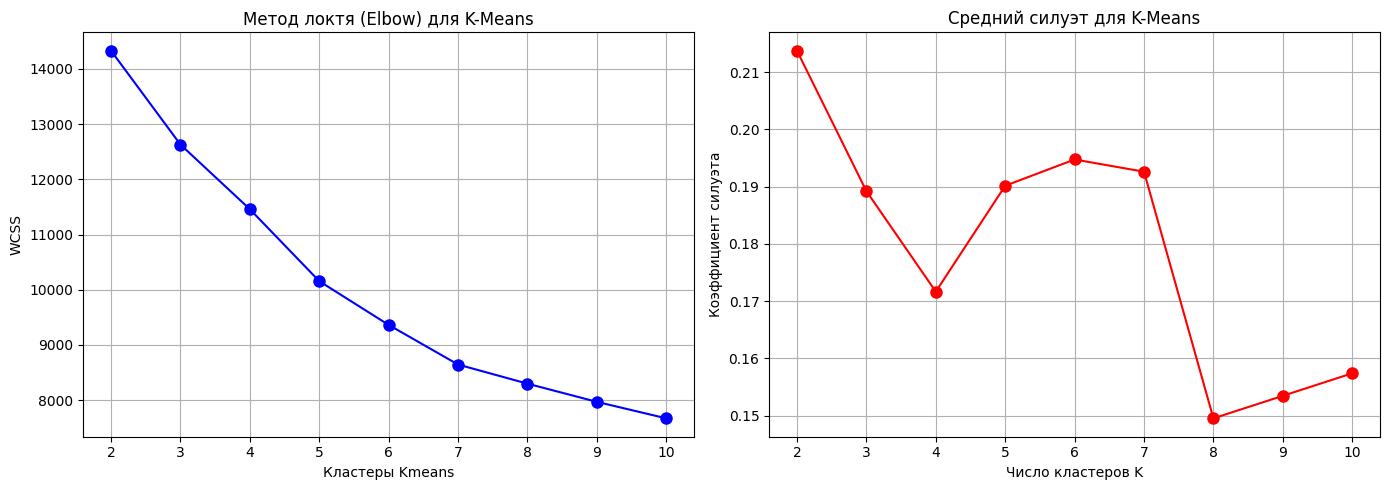

In [85]:
#Графики с Kmeans и WCSS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range_n_clusters, wcss, 'bo-', markersize=8)
ax1.set_xlabel('Кластеры Kmeans')
ax1.set_ylabel('WCSS')
ax1.set_title('Метод локтя (Elbow) для K-Means')
ax1.grid(True)

ax2.plot(range_n_clusters, silhouette_scores, 'ro-', markersize=8)
ax2.set_xlabel('Число кластеров K')
ax2.set_ylabel('Коэффициент силуэта')
ax2.set_title('Средний силуэт для K-Means')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [86]:
#Оптимальное k для силуэта
optimal_k = range_n_clusters[np.argmax(silhouette_scores)]
print(f"\nОптимальное число кластеров по силуэту: {optimal_k}")


Оптимальное число кластеров по силуэту: 2


In [87]:
#Обучение kmeans с выбранными параметрами
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

In [88]:
#Вывод силуэта
score = silhouette_score(X_scaled, kmeans_labels)
print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.214


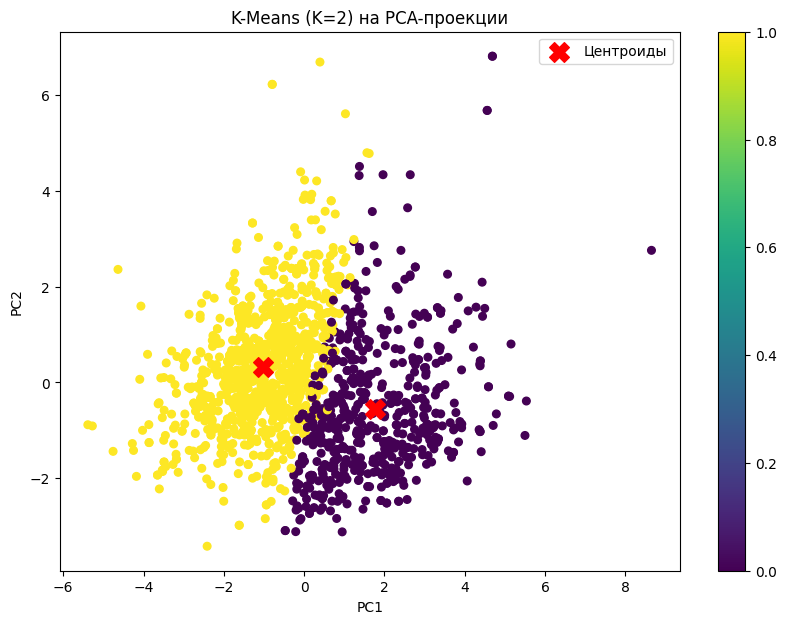

In [89]:
#Построение графика PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=kmeans_labels, cmap='viridis', s=30)
centroids_pca = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='X',
            c='red', s=200, label='Центроиды')
plt.title(f'K-Means (K={optimal_k}) на PCA-проекции')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.colorbar(scatter)
plt.show()

# Часть 2. DBSCAN

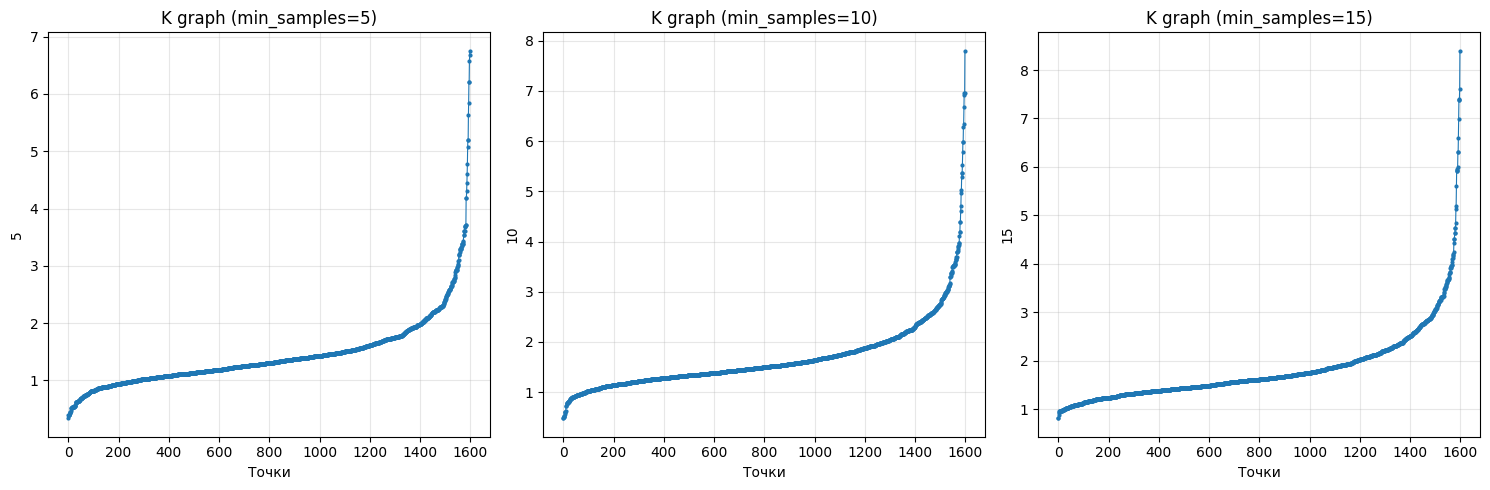

In [90]:
#Построила график k distance
def plot_k_distance_graph(X, min_samples_list=[5,10,15]):
    n_plots = len(min_samples_list)
    fig, axes = plt.subplots(1, n_plots, figsize=(5*n_plots, 5))
    if n_plots == 1:
        axes = [axes]
    for ax, k in zip(axes, min_samples_list):
        neighbors = NearestNeighbors(n_neighbors=k)
        neighbors_fit = neighbors.fit(X)
        distances, _ = neighbors_fit.kneighbors(X)
        k_distances = np.sort(distances[:, -1])
        ax.plot(k_distances, marker='o', markersize=2, linewidth=0.8)
        ax.set_xlabel('Точки')
        ax.set_ylabel(f'{k}')
        ax.set_title(f'K graph (min_samples={k})')
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_k_distance_graph(X_scaled)

In [91]:
#нахожу параметры методом перебора
eps_values = np.arange(0.3, 1.2, 0.1)
min_samples_values = [5, 10, 15]

best_score = -1
best_params = []
best_labels = []

for min_samples in min_samples_values:
    for eps in eps_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_ratio = n_noise / len(labels)

        if n_clusters >= 2 and noise_ratio <= 0.8:
                sil_score = silhouette_score(X_scaled, labels)
                if sil_score > best_score:
                    best_score = sil_score
                    best_params = (eps, min_samples)
                    best_labels = labels
                print(f"eps={eps}, min_samples={min_samples}: "
                f"clusters={n_clusters}, noise={noise_ratio},"
                f"silhouette={sil_score}")


print(f"\nЛучшие параметры: eps={best_params[0]},"
                    f"min_samples={best_params[1]}")
print(f"Лучший silhouette score: {best_score}")

eps=1.0000000000000002, min_samples=5: clusters=24, noise=0.7285803627267042,silhouette=-0.3177896958505555
eps=1.1000000000000003, min_samples=5: clusters=18, noise=0.5872420262664165,silhouette=-0.3202939188146475
eps=1.1000000000000003, min_samples=10: clusters=7, noise=0.7717323327079425,silhouette=-0.22388308075627192

Лучшие параметры: eps=1.1000000000000003,min_samples=10
Лучший silhouette score: -0.22388308075627192


In [98]:
#обучение dbscan
if best_params:
    dbscan_final = DBSCAN(eps=best_params[0],
                          min_samples=best_params[1])
    dbscan_labels = dbscan_final.fit_predict(X_scaled)

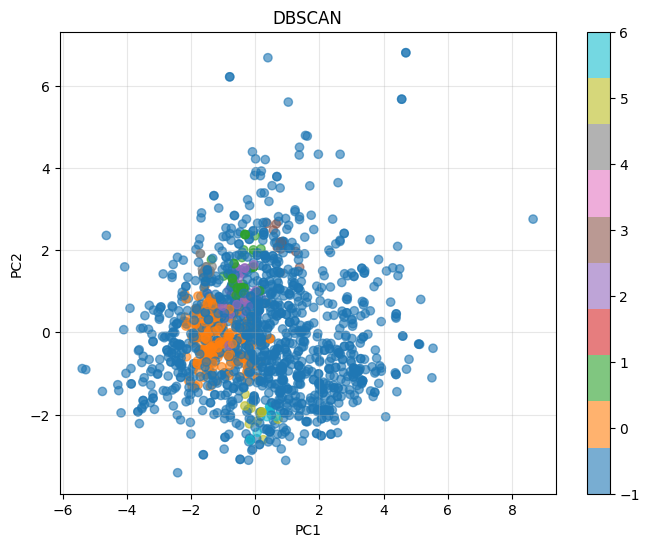

Количество шумовых точек: 1234(77.17%)


In [93]:
#построение графика
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels,
                      cmap='tab10', alpha=0.6)
plt.colorbar(scatter)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'DBSCAN')
plt.grid(alpha=0.3)
plt.show()

n_noise = list(dbscan_labels).count(-1)
print(f"Количество шумовых точек: {n_noise}"
          f"({n_noise/len(dbscan_labels):.2%})")

# Ответы на вопросы: DBSCAN

1. Почему для DBSCAN критически важно масштабировать данные?

Если не масштабировать данные в методе DBSCAN, то параметры с разными величинами могут исказить результаты. Например, точки будут слишком близкими или далекими. Параметры eps и min_samples станут несогласованными. Реальные кластеры могут быть не найдены.

2. Что будет при слишком маленьком `eps`? Слишком большом?

При слишком маленьком eps точки будут узкими, не будут иметь достаточное количество соседей в пределах eps, станут шумом, плотные области могут распаться на кластеры и остаться нераспознанными.
При слишком большом eps точки могут объединиться в один большой кластер. Это мешает обработке данных.

3. Что означают точки с меткой `-1`?

Точки с меткой -1 означают шум. Они не входят ни в один кластер. Отличается по плотности от других точек.

4. Чем DBSCAN принципиально отличается от K‑Means по форме кластеров?

У метода DBSCAN форма кластеров может быть любая, в то воемя как K-Means использует выпуклые кластеры. DBSCAN автоматически определяет количество кластеров. DBSCAN помечает выбросы как шум, метод не чувcтвителен к выбросам в отличие от K-Means.

# Часть 3. Optics

In [94]:
#Обучаем optics
optics = OPTICS(min_samples = 10,
                xi = 0.05,
                min_cluster_size = 0.05)
optics_labels = optics.fit_predict(X_scaled)


In [95]:
n_clusters = len(set(optics_labels)) - (1 if -1 in optics_labels else 0)
n_noise = list(optics_labels).count(-1)
print(f"Количество кластеров: {n_clusters}")
print(f"Количество шумовых точек: {n_noise}"
        f"{n_noise/len(optics_labels):.2%})")

if n_clusters >= 2:
    sil_score = silhouette_score(X_scaled, optics_labels)
    print(f"Silhouette Score: {sil_score:.4f}")
else:
    print("Недостаточно кластеров для вычисления силуэта")

Количество кластеров: 1
Количество шумовых точек: 00.00%)
Недостаточно кластеров для вычисления силуэта


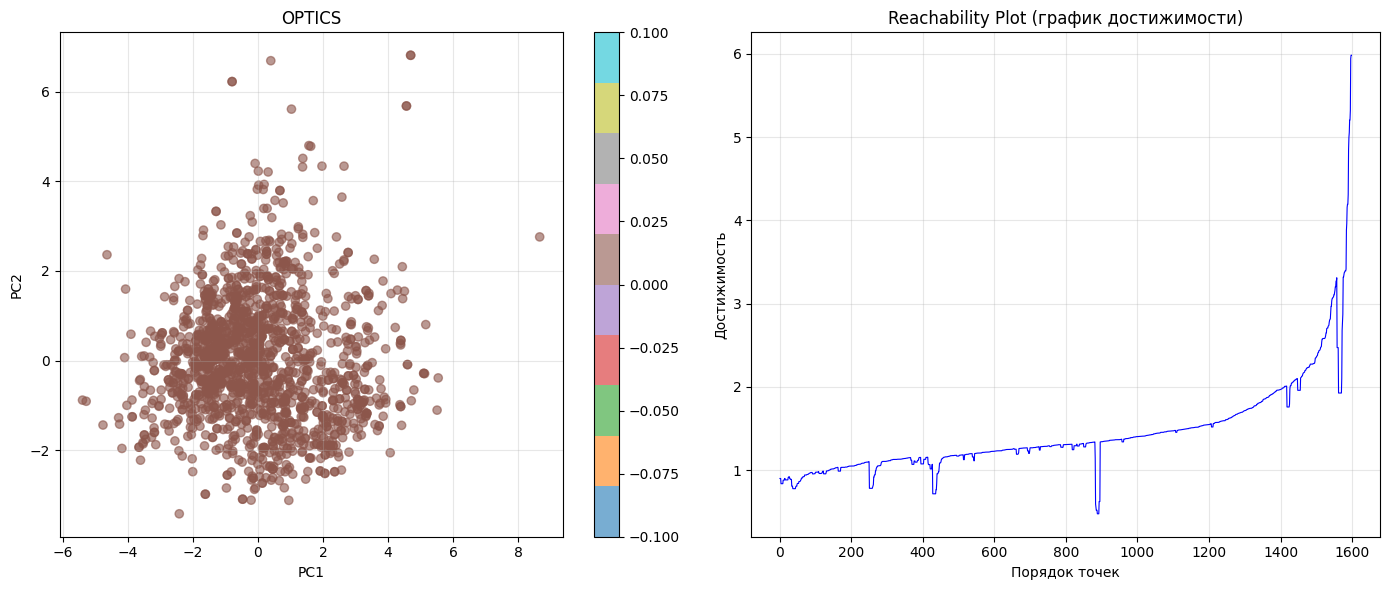

In [96]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Визуализация кластеров
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1],
                       c=optics_labels, cmap='tab10', alpha=0.6)
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_title('OPTICS')
ax1.grid(alpha=0.3)
plt.colorbar(scatter1, ax=ax1)

#визуализация reachability
reachability = optics.reachability_[optics.ordering_]
labels_ordered = optics_labels[optics.ordering_]

ax2.plot(range(len(reachability)), reachability, 'b-', linewidth=0.8)
ax2.set_xlabel('Порядок точек')
ax2.set_ylabel('Достижимость')
ax2.set_title('Reachability Plot (график достижимости)')
ax2.grid(alpha=0.3)


plt.tight_layout()
plt.show()

In [97]:
db_time = %timeit -o dbscan_final.fit(X_scaled)
opt_time = %timeit -o optics.fit(X_scaled)
print(f"DBSCAN время: {db_time} с")
print(f"OPTICS время: {opt_time} с")

197 ms ± 77.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.99 s ± 262 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
DBSCAN время: 197 ms ± 77.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each) с
OPTICS время: 1.99 s ± 262 ms per loop (mean ± std. dev. of 7 runs, 1 loop each) с


# Ответы на вопросы: OPTICS

 1. Чем OPTICS отличается от DBSCAN? Укажите **два ключевых отличия**.

OPTICS не требует фиксированного параметра eps, он работает с разной плотностью кластеров для любого набор данных в отличие от DBSCAN. Также DBSCAN дает плоскую разметку, а OPTICS строит reachability plot, с помощью которого можно увидеть иерархию кластеров с разной плотностью.

2. Что такое параметр `xi` (кси) и как он влияет на выделение кластеров?

Параметры xi выделяет границу крутизны для графиков с кластерами. Если сделать маленький параметр, то будет выделяться больше маленьких кластеров. Если сделать параметр большим, то выделяется меньше крупных кластеров.

3. В каком случае OPTICS даст результат, существенно лучший, чем DBSCAN? Приведите пример.

OPTICS даст лучший результат с данными разной плотности. OPTICS разделяет данные при помощи reachability plot, с помощью параметра xi из избирает кластеры с выбранной плотностью. Пример: данные о трафике в городе, разная плотность пробок, разное скопление машин. OPTICS даст лучшее разделение, чем DBSCAN.

4. Сравните время работы DBSCAN и OPTICS на ваших данных (можно замерить через `%timeit` или `time.time()`).

OPTICS работает дольше (время работы 1.93s), а DBSCAN быстрее(67.5 ms). Это связано с тем, что OPTICS разделяет плотность кластеров и строит иерархию плотности. Поэтому он работает дольше DBSCAN, который ориентируется в одной плоскости.

5. Судя по визуализациям, какой алгоритм (K‑Means, DBSCAN, OPTICS) лучше разделил данные? Почему?

Сравним значения силуэтов у разных методов. K-means: 0,214; лучший параметр DBSCAN: -0.2239. У OPTICS не был найден силуэт, так как настройка параметров позволила найти только один кластер. Следоватльно, с разделением данных справился только K-means. Возможно, это произошло из-за выпуклой формы кластеров и их одинаковой плотности.
